# Load the text data

In [1]:
import pandas as pd
import re

file_path = "/Users/evelynchu/Desktop/Blossom Shanghai.txt"

# read the file
with open(file_path, 'r', encoding='utf-16') as file:
    content = file.read()

content_cleaned = re.sub(r'\s+', '', content)


In [2]:
# 
sentences = re.findall(r'.+?[。！？!?]', content_cleaned)

# print top 10 sentences
for sentence in sentences[:10]:
    print(sentence)

沪生经过静安寺菜场，听见有人招呼，沪生一看，是陶陶，前女朋友梅瑞的邻居。
沪生说，陶陶卖大闸蟹了。
陶陶说，长远不见，进来吃杯茶。
沪生说，我有事体。
陶陶说，进来嘛，进来看风景。
沪生勉强走进摊位。
陶陶的老婆芳妹，低鬟一笑说，沪生坐，我出去一趟。
两个人坐进躺椅，看芳妹的背影，婷婷离开。
沪生说，身材越来越好了。
陶陶不响。


# Transfer txt format into csv format

In [3]:
import pandas as pd

df = pd.DataFrame({'text': sentences})
df.to_csv("/Users/evelynchu/Desktop/Blossom Shanghai_cleaned_sentences.csv",
          index=False,
          encoding='utf-8-sig')

df.head()

,text
0,沪生经过静安寺菜场，听见有人招呼，沪生一看，是陶陶，前女朋友梅瑞的邻居。
1,沪生说，陶陶卖大闸蟹了。
2,陶陶说，长远不见，进来吃杯茶。
3,沪生说，我有事体。
4,陶陶说，进来嘛，进来看风景。


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12591 entries, 0 to 12590
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    12591 non-null  object
dtypes: object(1)
memory usage: 98.5+ KB


In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


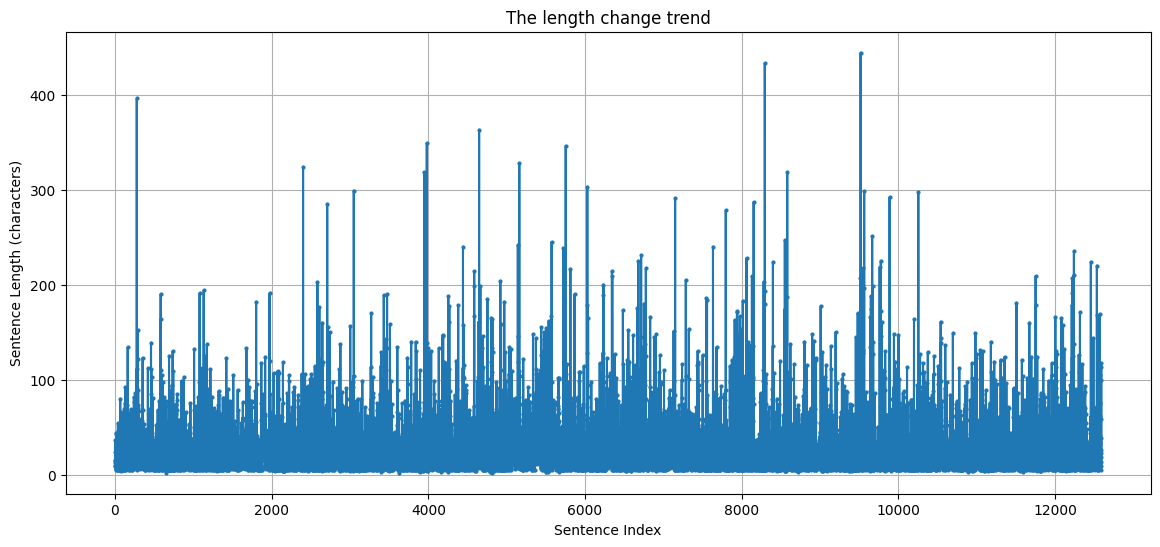

In [6]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['text'].str.len(), marker='o', linestyle='-', markersize=2)
plt.title('The length change trend')
plt.xlabel('Sentence Index')
plt.ylabel('Sentence Length (characters)')
plt.grid(True)
plt.show()


In [7]:
pip install PyMuPDF

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install music21

Note: you may need to restart the kernel to use updated packages.


In [10]:
from music21 import converter, note, chord

score = converter.parse('/Users/evelynchu/Desktop/succession 2.xml')

notes = []
for element in score.recurse():
    if isinstance(element, note.Note):
        notes.append({
            'type': 'note',
            'pitch': element.pitch.midi,
            'note_name': element.pitch.nameWithOctave,
            'duration': element.duration.quarterLength,
            'offset': element.offset
        })
    elif isinstance(element, chord.Chord):
        notes.append({
            'type': 'chord',
            'pitch': '-'.join(str(n.pitch.midi) for n in element.notes),
            'note_name': '-'.join(n.nameWithOctave for n in element.notes),
            'duration': element.duration.quarterLength,
            'offset': element.offset
        })

notes_df = pd.DataFrame(notes)

print(notes_df.head())

    type     pitch    note_name  duration  offset
0  chord  72-79-84     C5-G5-C6       0.5     0.0
1  chord  68-75-80  A-4-E-5-A-5       0.5     0.5
2  chord  67-74-79     G4-D5-G5       0.5     1.0
3  chord  65-72-77     F4-C5-F5       0.5     1.5
4  chord  63-68-75  E-4-A-4-E-5       1.0     2.0


In [11]:
notes_df.to_csv('succession2_features.csv', index=False)

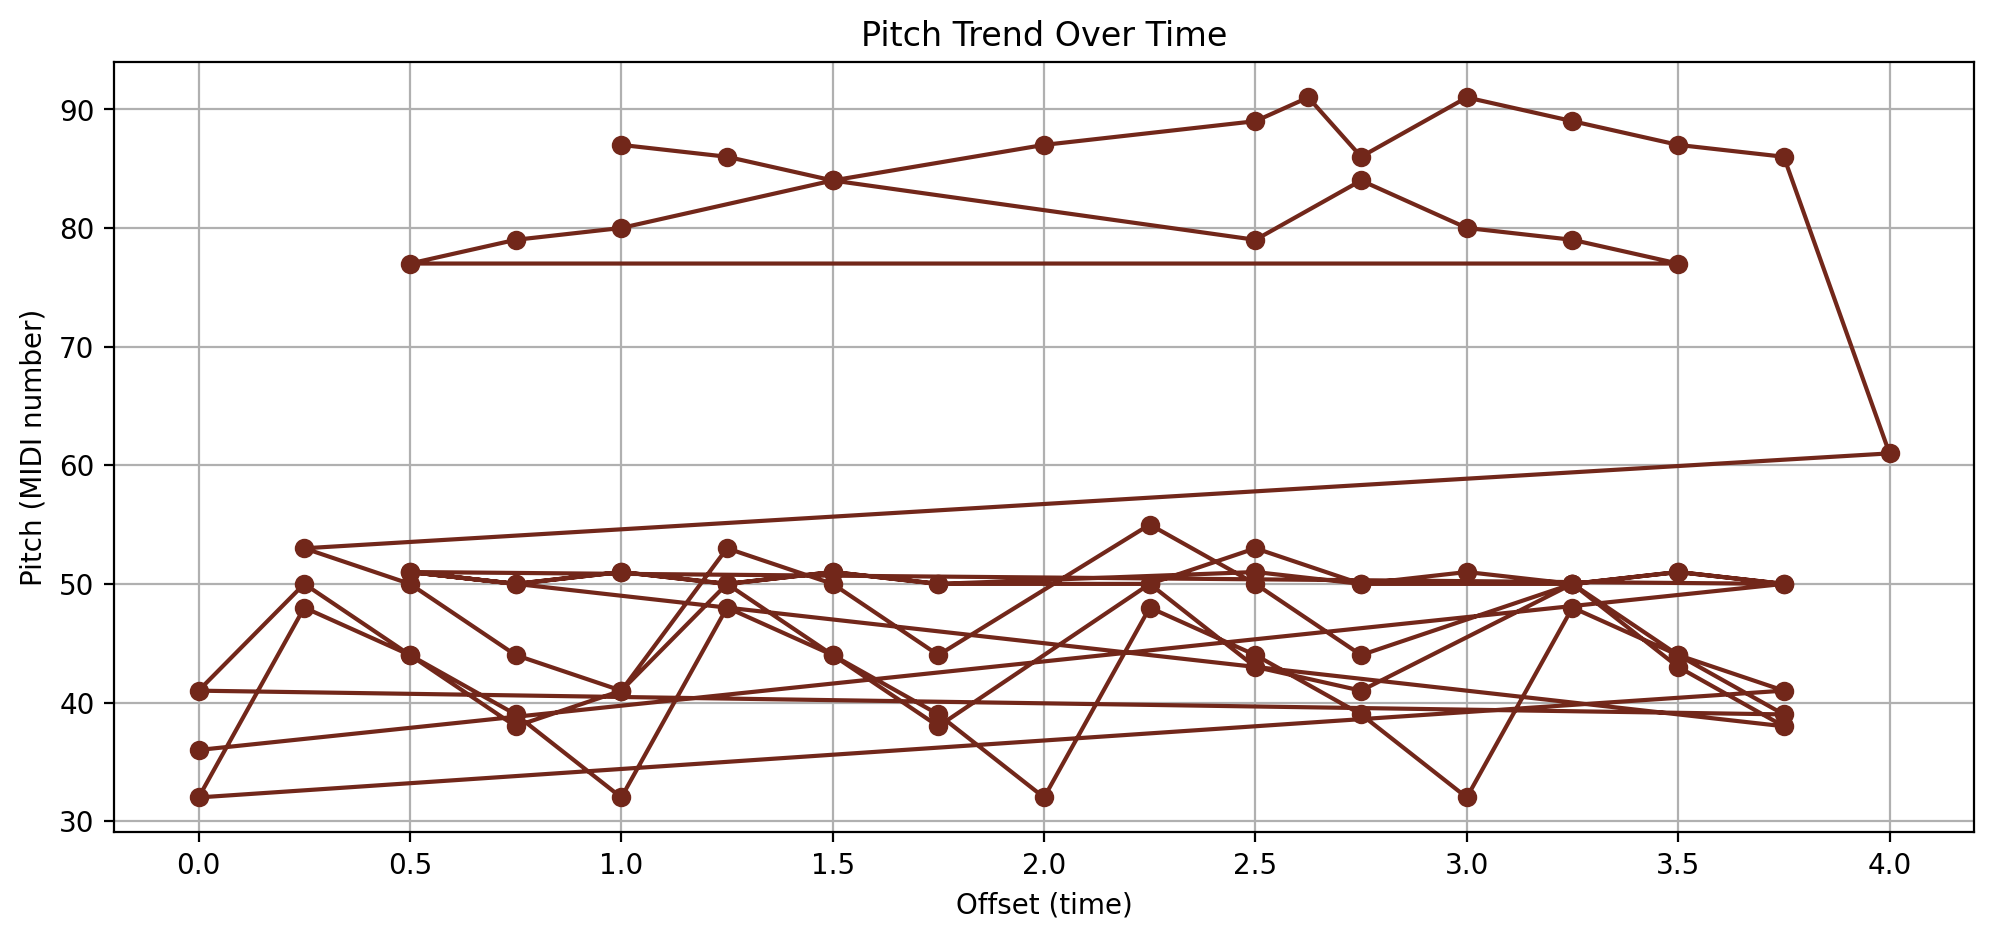

In [25]:
import matplotlib.pyplot as plt

notes_df_note_only = notes_df[notes_df['type'] == 'note']

plt.figure(figsize=(12, 5))
plt.plot(notes_df_note_only['offset'], notes_df_note_only['pitch'], marker='o', color='#72271A')
plt.title('Pitch Trend Over Time')
plt.xlabel('Offset (time)')
plt.ylabel('Pitch (MIDI number)')
plt.grid(True)
plt.show()



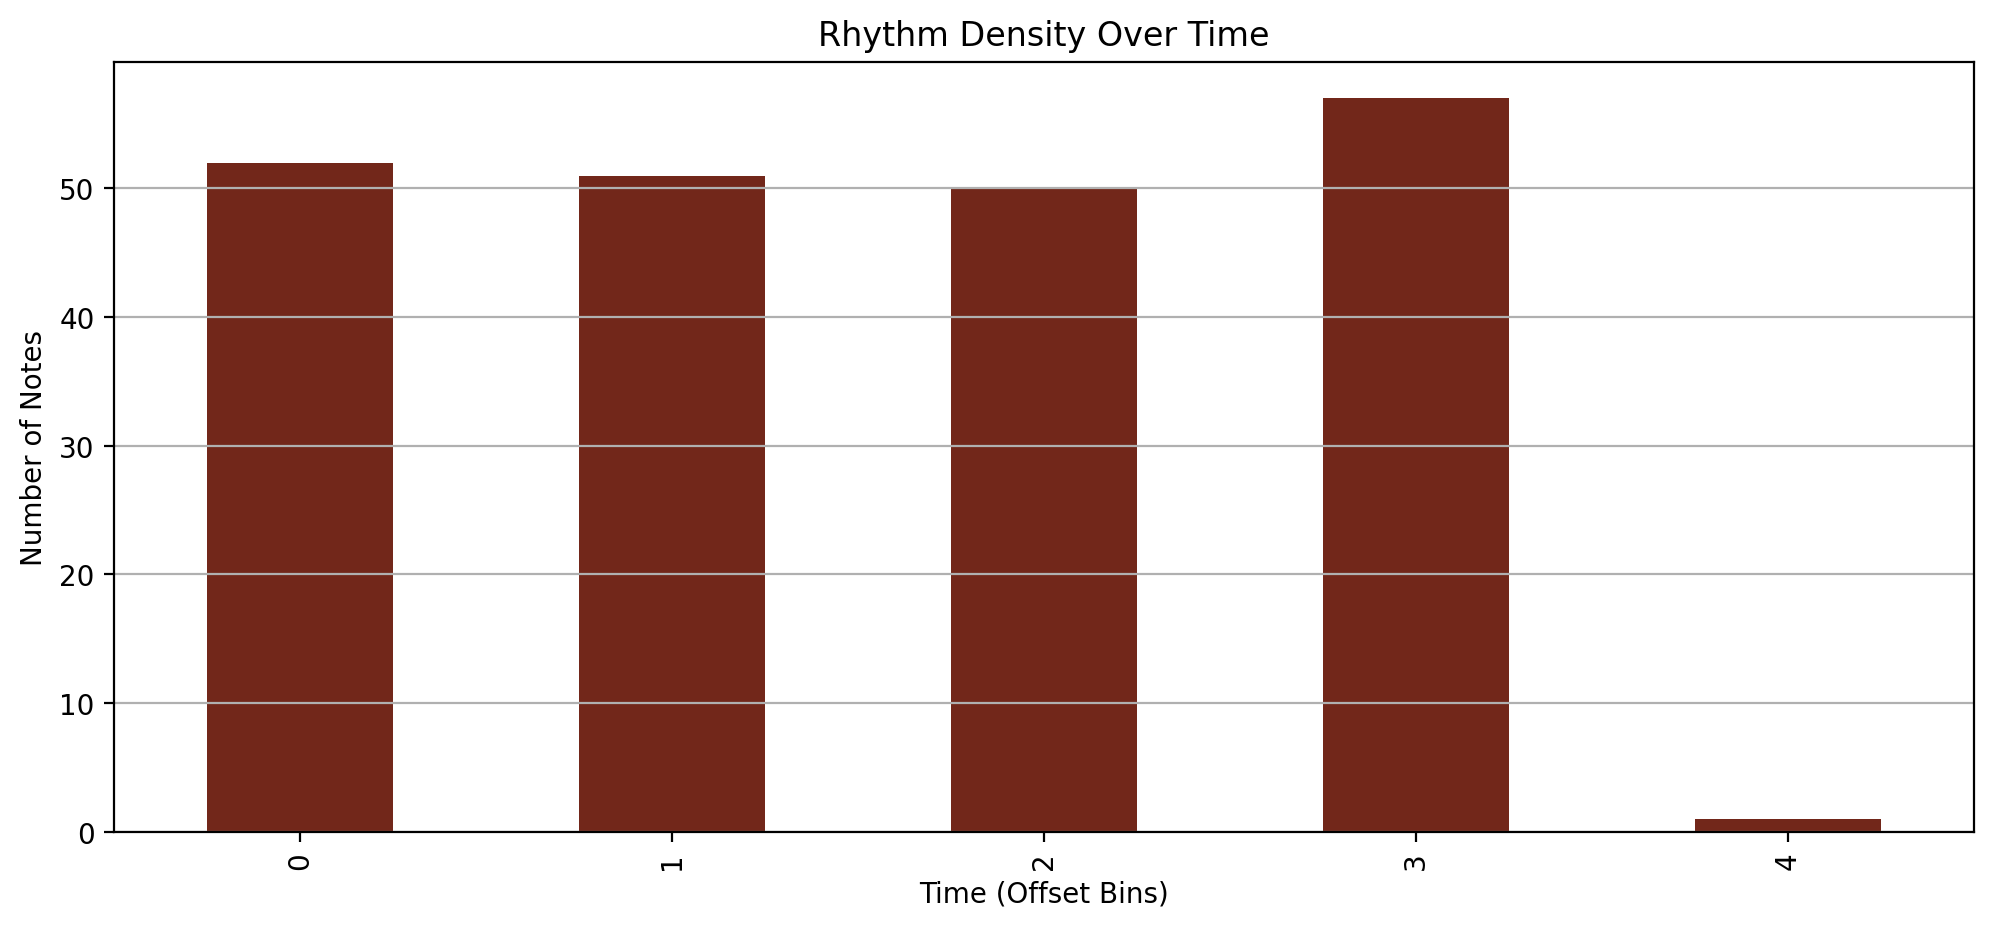

In [26]:
notes_df['offset_bin'] = notes_df['offset'].astype(int)

rhythm_density = notes_df.groupby('offset_bin').size()

plt.figure(figsize=(12, 5))
rhythm_density.plot(kind='bar', color='#72271A')
plt.title('Rhythm Density Over Time')
plt.xlabel('Time (Offset Bins)')
plt.ylabel('Number of Notes')
plt.grid(axis='y')
plt.show()


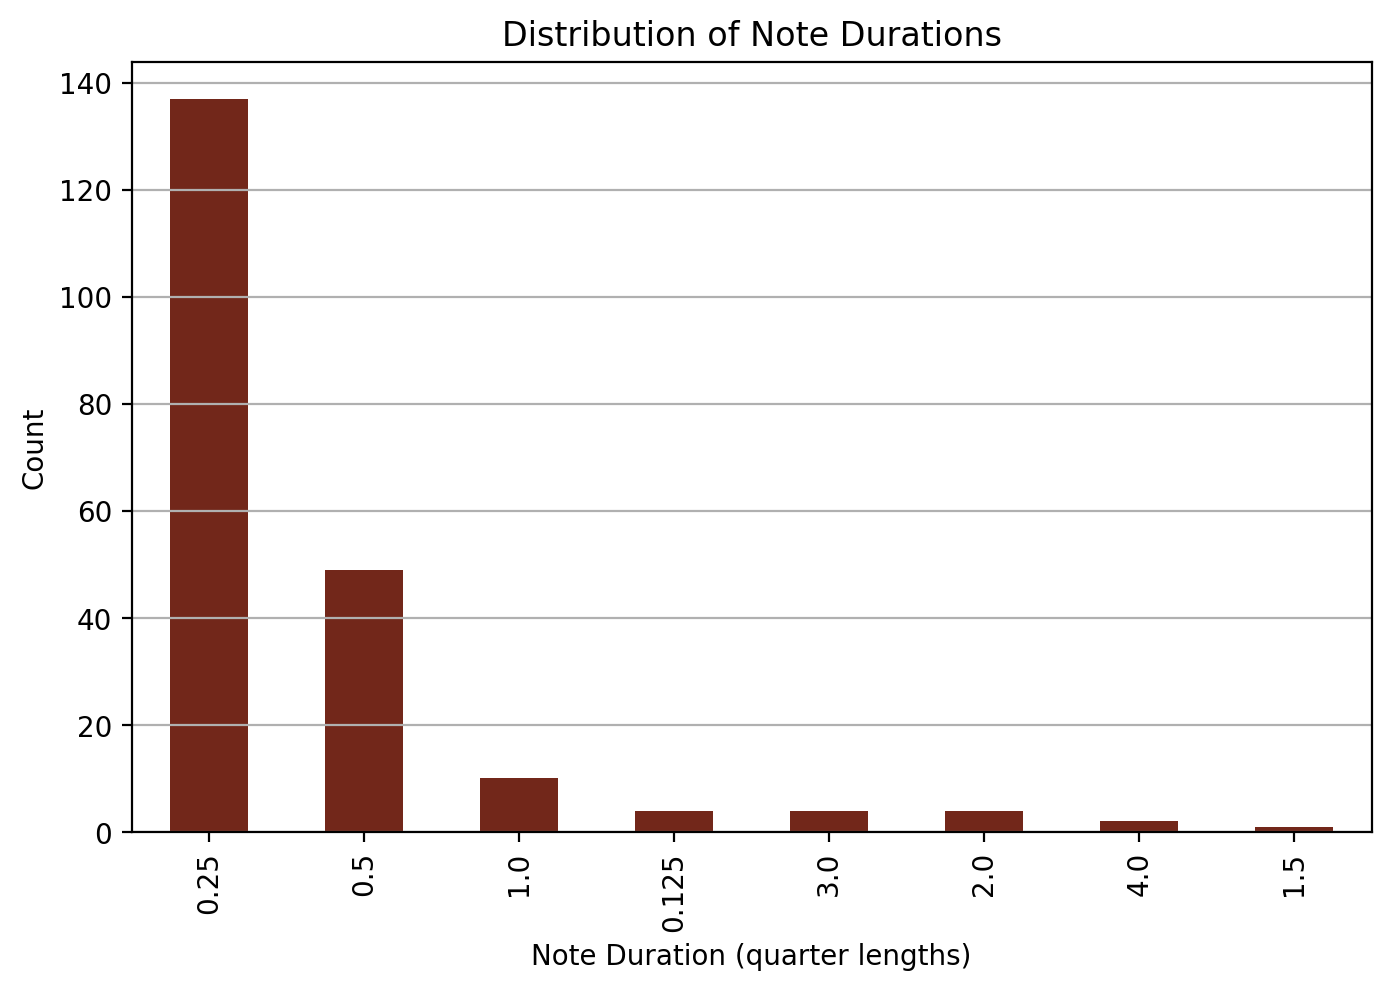

In [27]:
plt.figure(figsize=(8,5))
notes_df['duration'].value_counts().plot(kind='bar', color='#72271A')
plt.title('Distribution of Note Durations')
plt.xlabel('Note Duration (quarter lengths)')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show()


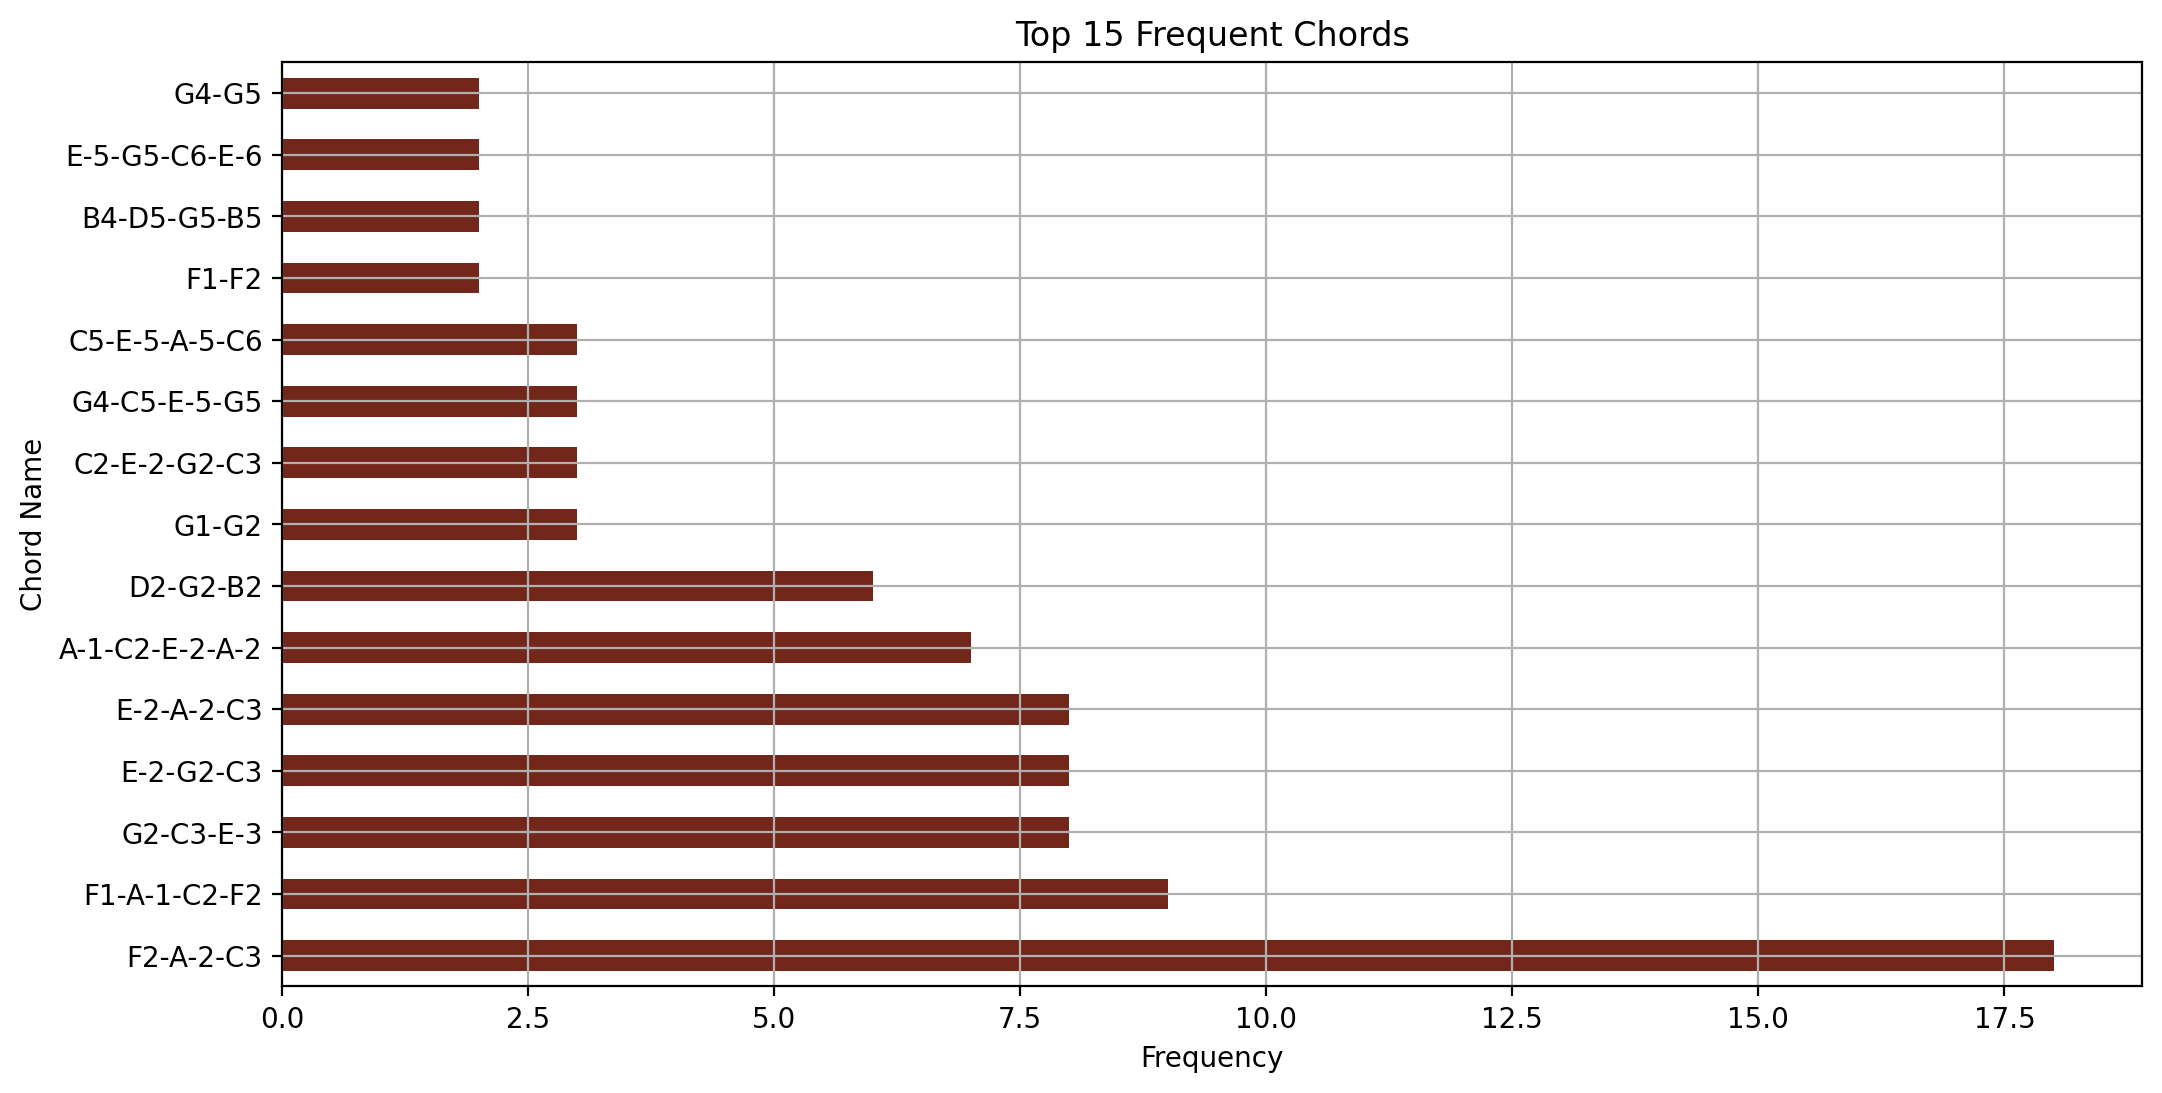

In [29]:
chord_df = notes_df[notes_df['type']=='chord']

plt.figure(figsize=(12,6))
chord_df['note_name'].value_counts().head(15).plot(kind='barh', color='#72271A')
plt.title('Top 15 Frequent Chords')
plt.xlabel('Frequency')
plt.ylabel('Chord Name')
plt.grid(True)
plt.show()



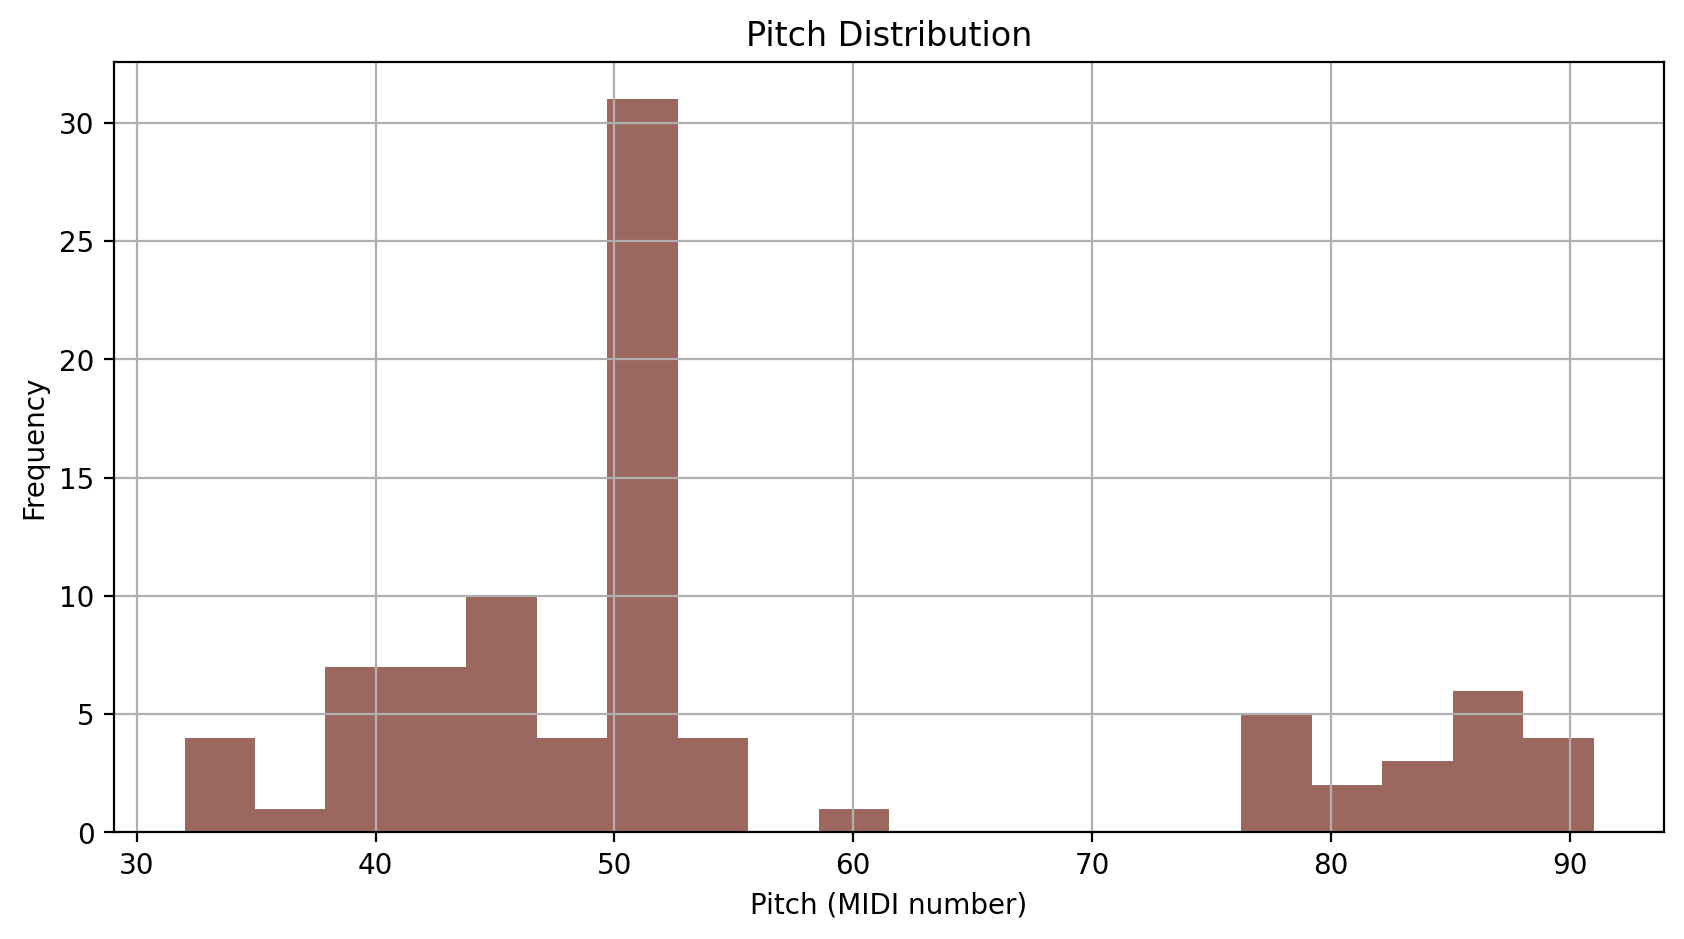

In [23]:
plt.figure(figsize=(10,5))
notes_df_note_only['pitch'].plot(kind='hist', bins=20, alpha=0.7, color='#72271A')
plt.title('Pitch Distribution')
plt.xlabel('Pitch (MIDI number)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()



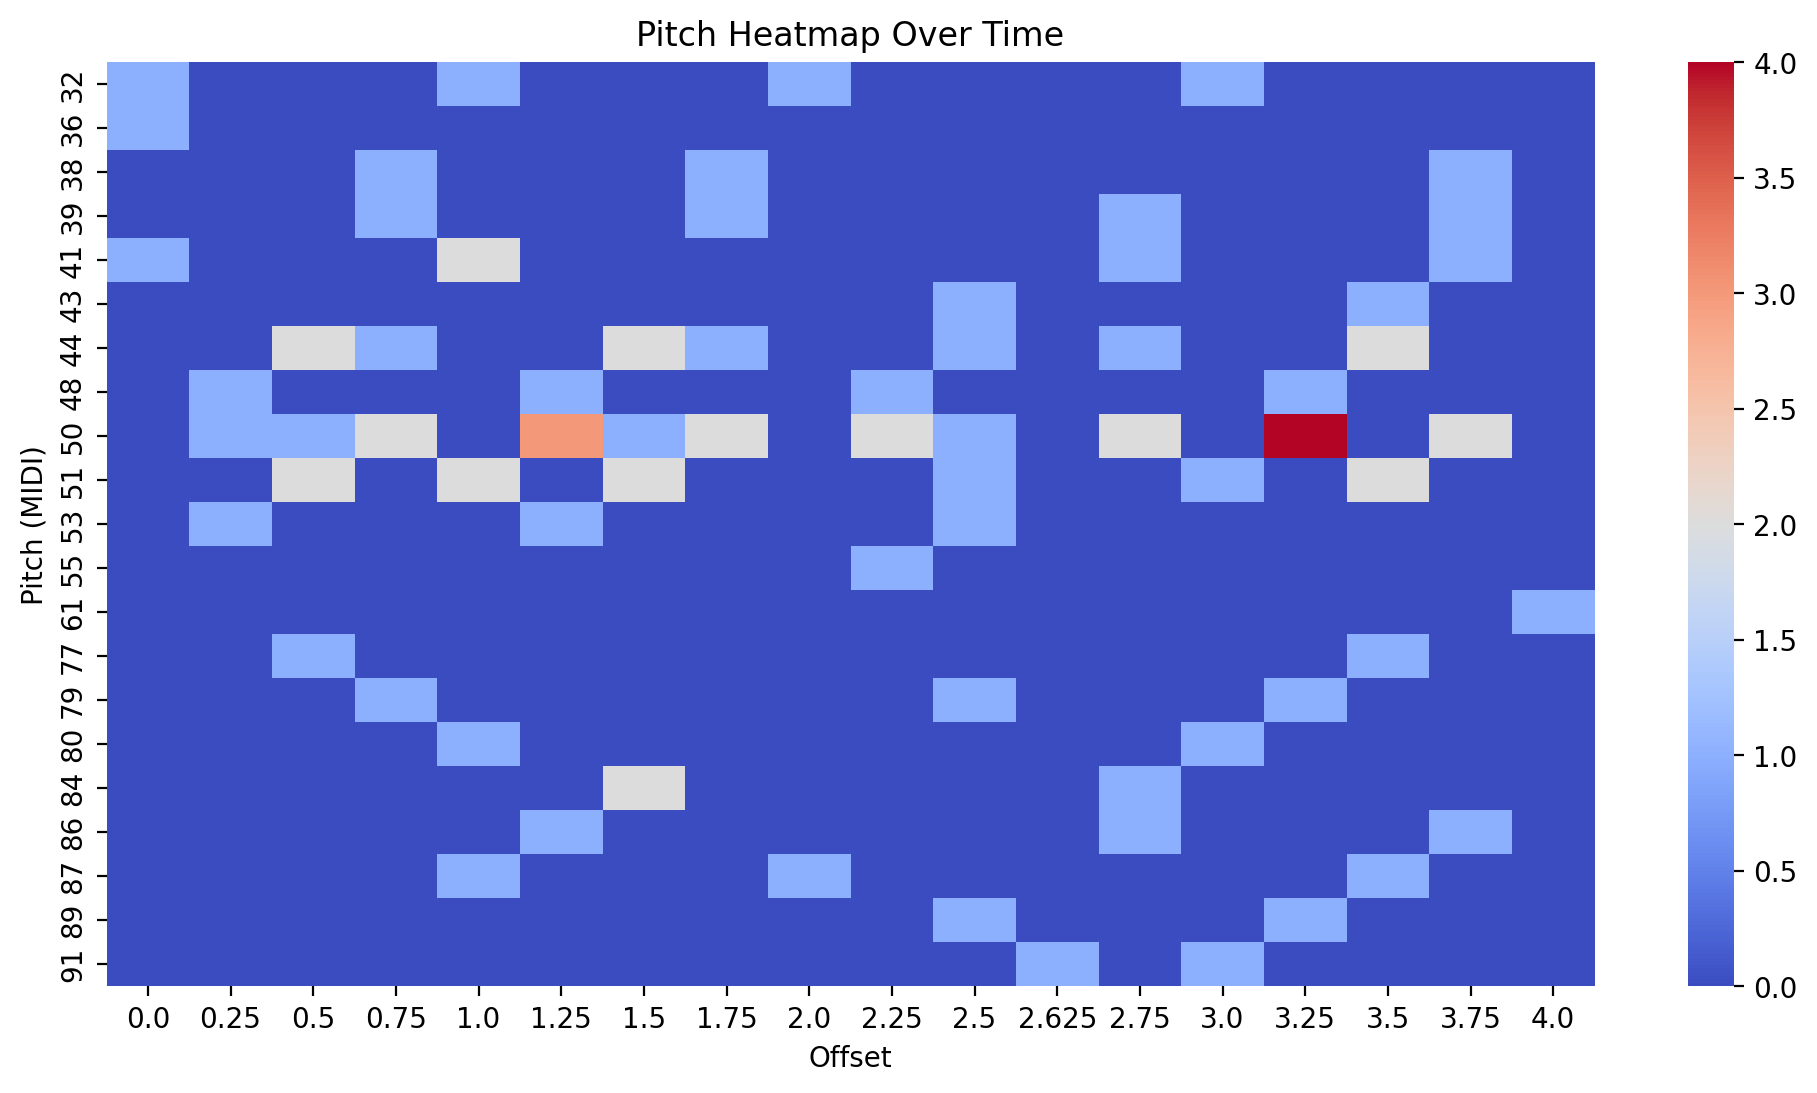

In [17]:
import seaborn as sns

pivot_table = notes_df_note_only.pivot_table(index='pitch', columns='offset', aggfunc='size', fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap='coolwarm')
plt.title('Pitch Heatmap Over Time')
plt.xlabel('Offset')
plt.ylabel('Pitch (MIDI)')
plt.show()
